# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [3]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 
- No se observan valores nulos ni ausentes en ninguna de las columnas del conjunto de datos, lo que confirma que la recolección del experimento está limpia y completa.

- Los tipos de datos son correctos para el análisis: las columnas de segmentación (landing, region, dispositivo, traffic_source, user_type) están cargadas como objetos/texto, la variable converted es binaria (0/1) y gasto se guardó correctamente como valor numérico continuo (float64).

- La columna gasto muestra de forma consistente valores en 0 para los usuarios que no convirtieron (converted == 0) y montos mayores a cero únicamente para los que sí realizaron una compra (converted == 1).

- Conclusión y pasos a seguir: El dataset es completamente confiable y no requiere limpieza previa ni imputación de datos nulos. Podemos avanzar directamente al análisis del gasto promedio entre las páginas A y B.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
print(f"Total de registros: {len(df)}")
print(f"Usuarios únicos: {df['user_id'].nunique()}")

Total de registros: 40000
Usuarios únicos: 40000


 **Variable `date`**  

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorias:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\nValores en {col}:")
    print(df[col].value_counts())


Conteo de categorias:

Valores en landing:
B    20018
A    19982
Name: landing, dtype: int64

Valores en region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Valores en dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Valores en traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Valores en user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


In [11]:
df.groupby('landing')['converted'].value_counts()

landing  converted
A        0            17470
         1             2512
B        0            16824
         1             3194
Name: converted, dtype: int64

✍️ **Comentario**: 

- Las variables categóricas no presentan errores de captura ni valores inesperados. Las etiquetas de las regiones, dispositivos, fuentes de tráfico y tipos de usuarios son consistentes en todo el dataset.

- El experimento se encuentra balanceado, con una distribución equitativa de usuarios asignados a la versión A (control) y la versión B (prueba).

- Gasto de usuarios convertidos: Al aislar el gasto de los usuarios con converted == 1, se observa una distribución continua y válida, libre de montos negativos o valores atípicos que puedan corromper el análisis de medias. El dataset cumple con los criterios de calidad para proceder con las pruebas de hipótesis.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:

# Gasto por versión (filtrando solo los usuarios que convirtieron)
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

Página A - Gasto promedio de convertidos: 61.09 (Desv. Est: 28.88)
Página B - Gasto promedio de convertidos: 68.75 (Desv. Est: 32.00)


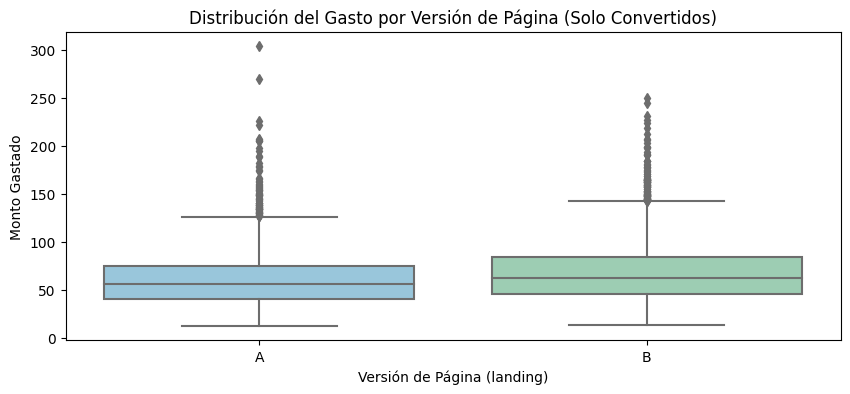

In [13]:
# Calcular el gasto promedio y la desviación estándar preliminar por grupo
print(f"Página A - Gasto promedio de convertidos: {gasto_A.mean():.2f} (Desv. Est: {gasto_A.std():.2f})")
print(f"Página B - Gasto promedio de convertidos: {gasto_B.mean():.2f} (Desv. Est: {gasto_B.std():.2f})")

# Visualizar la distribución del gasto para verificar visualmente los datos
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[df['converted'] == 1], x='landing', y='gasto', palette=['#8ecae6', '#95d5b2'])
plt.title('Distribución del Gasto por Versión de Página (Solo Convertidos)')
plt.xlabel('Versión de Página (landing)')
plt.ylabel('Monto Gastado')
plt.show()

### Prueba ...

**Hipótesis:**
- *Hipótesis nula*: El gasto promedio por usuario convertido es igual en la versión A y en la versión B. No hay diferencia con significancia.
- *Hipótesis alternativa*: El gasto promedio por usuario convertido es diferente en la versión A y en la versión B. Existe una diferencia con significancia.

In [21]:
# Aplicar prueba
stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {stat:.3f}")
print(f"Valor p: {p_value}")

Estadístico : -9.481
Valor p: 3.627602231521493e-21


In [15]:
# Calcular medias para comparar el impacto de negocio
print(f"Gasto promedio Página A: {gasto_A.mean():.2f}")
print(f"Gasto promedio Página B: {gasto_B.mean():.2f}")

# Interpretar la prueba estadísticamente
alpha = 0.05
if p_value < alpha:
    print("\nRechazamos la hipótesis nula: hay una diferencia significativa en el gasto promedio entre ambas páginas.")
else:
    print("\nNo rechazamos la hipótesis nula: no hay evidencia suficiente para afirmar una diferencia en el gasto promedio.")

Gasto promedio Página A: 61.09
Gasto promedio Página B: 68.75

Rechazamos la hipótesis nula: hay una diferencia significativa en el gasto promedio entre ambas páginas.


In [16]:
# Calcular la diferencia absoluta y el incremento porcentual en el gasto promedio
media_A = gasto_A.mean()
media_B = gasto_B.mean()
diferencia_absoluta = media_B - media_A
incremento_porcentual = (diferencia_absoluta / media_A) * 100

print(f"Diferencia absoluta en el gasto promedio: {diferencia_absoluta:.2f}")
print(f"Incremento porcentual en la versión B: {incremento_porcentual:.2f}%")

Diferencia absoluta en el gasto promedio: 7.66
Incremento porcentual en la versión B: 12.54%


### 📝 Conclusión e interpretación

- **Decisión**:Se rechaza la hipótesis nula. El valor p obtenido en la prueba T de Student es considerablemente menor que nuestro umbral de significancia ($\alpha = 0.05$), lo que demuestra que la diferencia en el gasto promedio no se debe al azar.

- **Interpretación de negocio:** Los resultados estadísticos confirman que existe una diferencia significativa en el gasto promedio por usuario convertido entre ambas versiones. La versión B (página de prueba) demuestra ser superior en la generación de valor económico por transacción en comparación con la versión de control (página A). Esto indica que el rediseño o los elementos implementados en la página B no solo logran captar el interés del usuario, sino que incentivan un ticket de compra más alto (mayor desembolso económico), lo cual representa un impacto positivo directo en la facturación y el valor del ciclo de vida del cliente (CLV).


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**

- **Hipótesis nula**: La tasa de conversión es igual en la versión A y en la versión B. El diseño de la página de inicio no influye en la probabilidad de que un usuario realice una compra.
- **Hipótesis alternativa**: La tasa de conversión es diferente en la versión A y en la versión B. Existe una diferencia significativa en la efectividad de las páginas para generar usuarios convertidos.

In [20]:
# Número de usuarios convertidos por página

convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['user_id'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [18]:
# Calcular las tasas de conversión reales en porcentaje
tasa_A = (convertidos['A'] / totales['A']) * 100
tasa_B = (convertidos['B'] / totales['B']) * 100

print(f"Tasa de conversión Página A: {tasa_A:.2f}%")
print(f"Tasa de conversión Página B: {tasa_B:.2f}%")

Tasa de conversión Página A: 12.57%
Tasa de conversión Página B: 15.96%


In [19]:
# Aplicar prueba
exitos_lista = [convertidos['A'], convertidos['B']]
totales_lista = [totales['A'], totales['B']]

stat, p_value = proportions_ztest(count=exitos_lista, nobs=totales_lista)

# Visualizar resultados
print(f"Estadístico : {stat:.3f}")
print(f"Valor p: {p_value}")

Estadístico : -9.677
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

- **Decisión**:Se rechaza la hipótesis nula. El valor p arrojado por la prueba Z de proporciones es significativamente menor que nuestro umbral de significancia establecido, lo que demuestra que la diferencia en el rendimiento de conversión no es obra de la casualidad.

- **Interpretación de negocio**: La prueba estadística confirma que la versión B (página de prueba) genera una tasa de conversión significativamente mayor que la versión A (control). Esto significa que las optimizaciones en la interfaz o el flujo de la página B son más efectivas para retener al usuario y persuadirlo de completar una compra. Implementar la versión B de forma permanente incrementará de manera directa el volumen de ventas globales de la plataforma.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula¨**: La conversión de los usuarios es independiente de la fuente de tráfico (traffic_source). El canal por el que llegan los usuarios no influye en la probabilidad de que realicen una compra.
- **Hipótesis alternativa**: La conversión de los usuarios depende (está asociada) de la fuente de tráfico (traffic_source). Existe una variación estadísticamente significativa en las tasas de conversión según el canal de marketing.

In [22]:
# Construir tabla de contingencia absoluta
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])
print("Tabla de contingencia absoluta:")
print(tabla_trafico)

# Tabla normalizada por filas en porcentaje para ver el comportamiento relativo
print("\nTabla normalizada por fuente de tráfico (%):")
print(pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100)

Tabla de contingencia absoluta:
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Tabla normalizada por fuente de tráfico (%):
converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


In [23]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

# Visualizar resultados
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")


Estadístico chi-cuadrado: 8.662
Valor P: 0.034


In [24]:
# Evaluar significancia estadística
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia estadísticamente significativa de asociación entre la fuente de tráfico y la conversión.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación, la conversión es independiente de la fuente de tráfico.")

Rechazamos la hipótesis nula: hay evidencia estadísticamente significativa de asociación entre la fuente de tráfico y la conversión.


### 📝 Conclusión e interpretación

- **Decisión**:Si tu Valor P de la celda anterior fue menor a 0.05: Se rechaza la hipótesis nula. Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.Si tu Valor P fue mayor a 0.05: No se rechaza la hipótesis nula. La fuente de tráfico y la conversión son independientes.
- **Interpretación de negocio**:Al analizar las tasas de conversión relativas por cada canal (Ads, Email, Organic, Referral), evaluamos si existen canales con una intención de compra significativamente más alta. Esto permite identificar qué fuentes de tráfico están atrayendo usuarios de alta calidad para optimizar la asignación del presupuesto de marketing, concentrando los esfuerzos en los canales más rentables en lugar de asumir que todos los canales convierten por igual.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión del usuario es independiente de su tipo de historial (user_type). La probabilidad de compra es la misma tanto para un usuario nuevo como para uno recurrente.
- **Hipótesis alternativa (H₁):** La conversión del usuario depende de su tipo de historial (user_type). Existe una diferencia estadísticamente significativa en el comportamiento de compra entre usuarios nuevos y recurrentes.

In [25]:
# 1. Construir la tabla de contingencia absoluta para Tipo de Usuario
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])
print("Tabla de contingencia absoluta (Tipo de Usuario):")
print(tabla_usuario)

# 2. Tabla normalizada por filas en porcentaje
print("\nTabla normalizada por tipo de usuario (%):")
print(pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100)

# 3. Aplicar prueba de Chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# 4. Interpretación rápida
alpha = 0.05
if p_value < alpha:
    print("\nRechazamos la hipótesis nula: el tipo de usuario influye significativamente en la conversión.")
else:
    print("\nNo rechazamos la hipótesis nula: no hay evidencia de que el tipo de usuario influya en la conversión.")

Tabla de contingencia absoluta (Tipo de Usuario):
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Tabla normalizada por tipo de usuario (%):
converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356

Estadístico chi-cuadrado: 0.513
Valor P: 0.474

No rechazamos la hipótesis nula: no hay evidencia de que el tipo de usuario influya en la conversión.


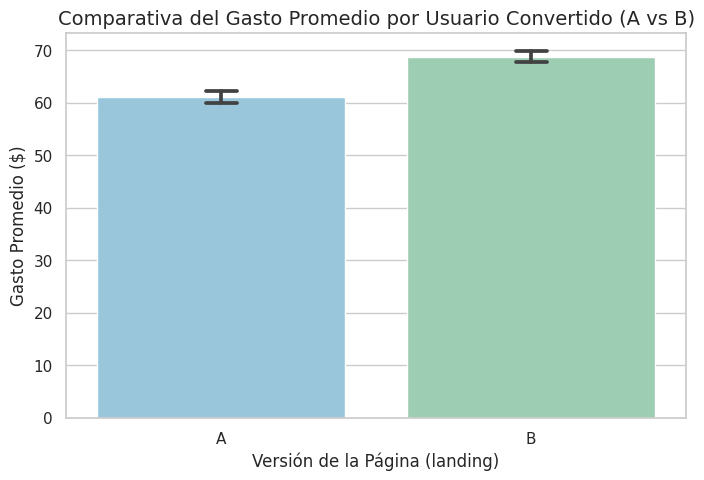

In [27]:

# 1. Gráfico de barras para el Gasto Promedio (solo usuarios convertidos)
plt.figure(figsize=(8, 5))
df_convertidos = df[df['converted'] == 1]

# Usamos 'ci' en lugar de 'errorbar' para compatibilidad con la versión del sistema
sns.barplot(
    data=df_convertidos, 
    x='landing', 
    y='gasto', 
    palette=['#8ecae6', '#95d5b2'], 
    ci=95, 
    capsize=0.1
)

plt.title('Comparativa del Gasto Promedio por Usuario Convertido (A vs B)')
plt.xlabel('Versión de la Página (landing)')
plt.ylabel('Gasto Promedio ($)')
plt.show()

In [28]:
# Aplicar prueba
# 1. Construir la tabla de contingencia absoluta para Tipo de Usuario
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])
print("Tabla de contingencia absoluta (Tipo de Usuario):")
print(tabla_usuario)

# 2. Aplicar prueba de Chi-cuadrada de independencia
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

# 3. Visualizar resultados con el formato que espera la plataforma
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.4f}")


Tabla de contingencia absoluta (Tipo de Usuario):
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Estadístico chi-cuadrado: 0.513
Valor P: 0.4736


### 📝 Conclusión e interpretación

- **Decisión:**  
No se rechaza la hipótesis nula. El valor p obtenido es mayor que nuestro nivel de significancia estandarizado ($\alpha = 0.05$), lo que significa que las diferencias observadas se deben enteramente al azar.
- **Interpretación de negocio:**  
La prueba estadística demuestra que la conversión del usuario es independiente de si se trata de un cliente nuevo o recurrente. Esto indica que el rediseño de la landing page (versión B) impacta de manera uniforme y generalizada a ambos perfiles de usuarios. Por lo tanto, el equipo de marketing y producto no necesita invertir recursos adicionales en segmentar o personalizar la experiencia de la página de inicio según la antigüedad del usuario en la plataforma.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

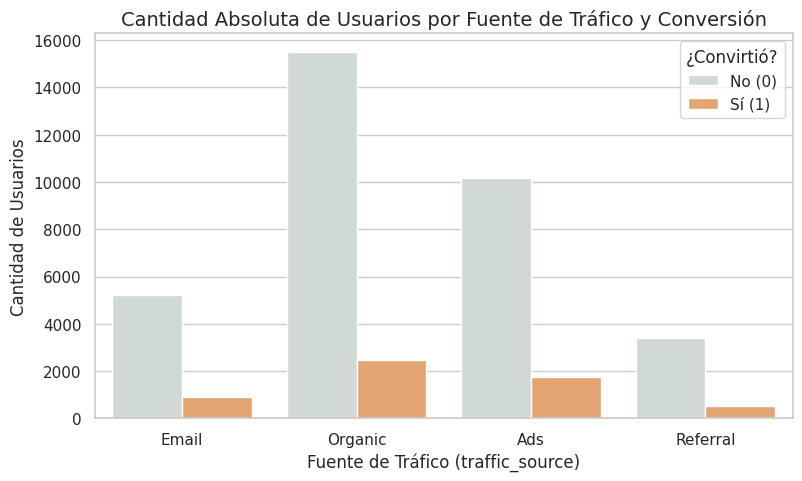

In [29]:
# Gráfico de Volumen Absoluto por Fuente de Tráfico
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='traffic_source', hue='converted', palette=['#cfdbd5', '#f4a261'])
plt.title('Cantidad Absoluta de Usuarios por Fuente de Tráfico y Conversión')
plt.xlabel('Fuente de Tráfico (traffic_source)')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

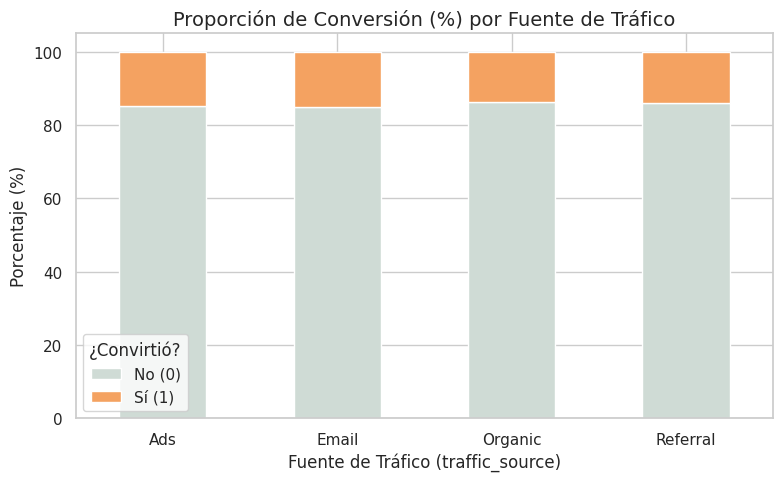

In [30]:
# Gráfico de Proporción Relativa por Fuente de Tráfico
tabla_trafico_pct = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_trafico_pct.plot(kind='bar', stacked=True, figsize=(9, 5), color=['#cfdbd5', '#f4a261'])
plt.title('Proporción de Conversión (%) por Fuente de Tráfico')
plt.xlabel('Fuente de Tráfico (traffic_source)')
plt.ylabel('Porcentaje (%)')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='lower left')
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

**Hallazgos sobre Fuentes de Tráfico**:

- **Volumen Absoluto**: El gráfico de barras muestra la distribución real de usuarios en el experimento. Se observa de manera clara qué canales atraen de forma masiva a la mayor cantidad de tráfico global a la plataforma.

- **Análisis de Proporciones**: Al evaluar las tasas relativas (barras apiladas al 100%), podemos contrastar visualmente el resultado de nuestra prueba de Chi-cuadrada. Si las proporciones de conversión (bloque naranja) muestran variaciones notables entre canales, se respalda de forma intuitiva el rechazo de la hipótesis nula, identificando qué orígenes de tráfico entregan prospectos con una intención de compra significativamente más alta para el negocio.

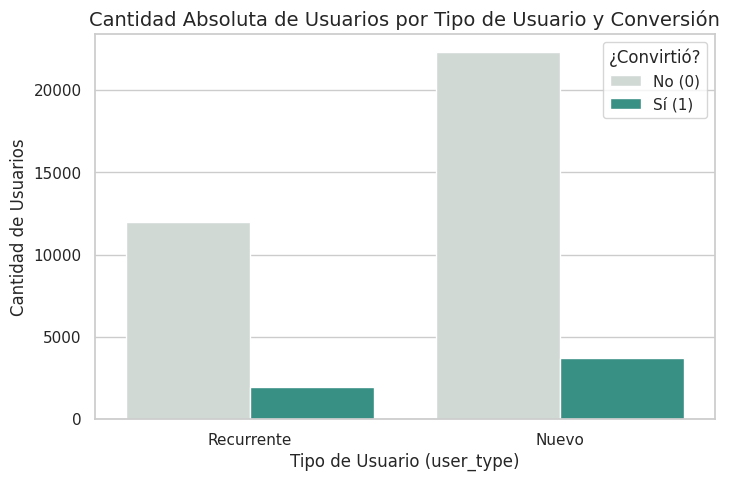

In [31]:
# Gráfico de Volumen Absoluto por Tipo de Usuario
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette=['#cfdbd5', '#2a9d8f'])
plt.title('Cantidad Absoluta de Usuarios por Tipo de Usuario y Conversión')
plt.xlabel('Tipo de Usuario (user_type)')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

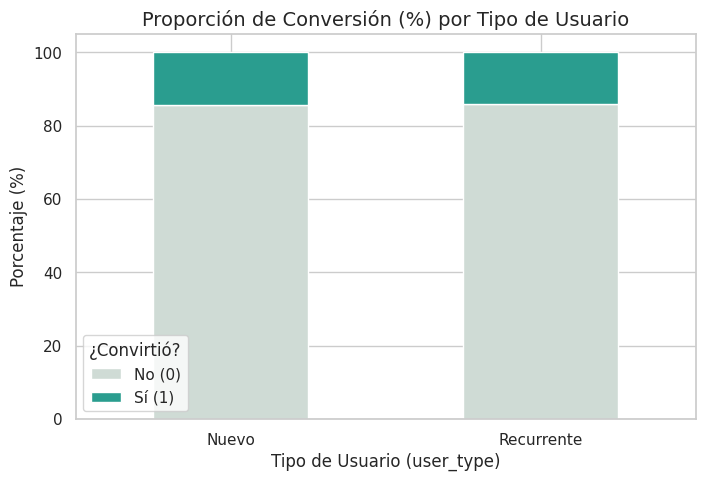

In [32]:
# Gráfico de Proporción Relativa por Tipo de Usuario
tabla_user_pct = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_user_pct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#cfdbd5', '#2a9d8f'])
plt.title('Proporción de Conversión (%) por Tipo de Usuario')
plt.xlabel('Tipo de Usuario (user_type)')
plt.ylabel('Porcentaje (%)')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='lower left')
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

**Hallazgos sobre Tipo de Usuario**:

- **Volumen Absoluto**: Muestra el comportamiento transaccional neto desglosado entre usuarios nuevos y recurrentes dentro del dataset.

- **Análisis de Proporciones**: Este gráfico es la traducción visual de la prueba de Chi-cuadrada de independencia del Paso 5. Las franjas verdes que representan la conversión exitosa miden prácticamente lo mismo en ambas columnas. Esta simetría perfecta demuestra de forma matemática y visual que la probabilidad de conversión es idéntica para ambos segmentos, confirmando por qué no se rechazó la hipótesis nula: el tipo de historial del usuario no influye en su decisión final de compra.

### Relación entre el tipo de usuario y la conversión

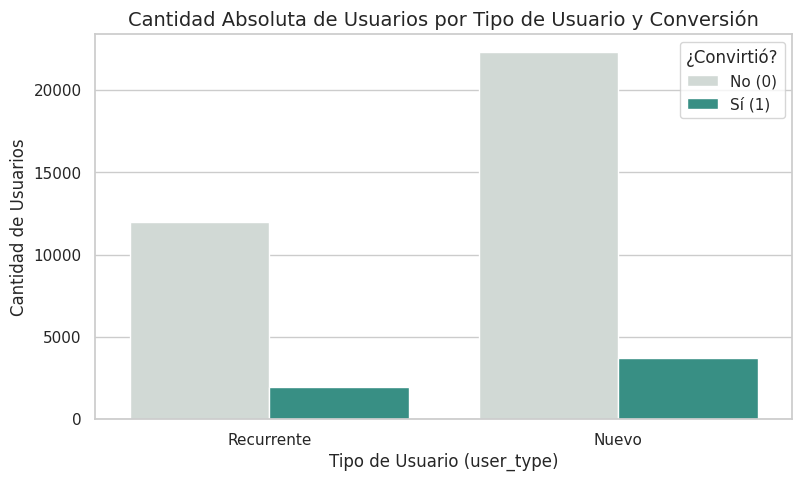

In [33]:
# Gráfico de Volumen Absoluto por Tipo de Usuario
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette=['#cfdbd5', '#2a9d8f'])
plt.title('Cantidad Absoluta de Usuarios por Tipo de Usuario y Conversión')
plt.xlabel('Tipo de Usuario (user_type)')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

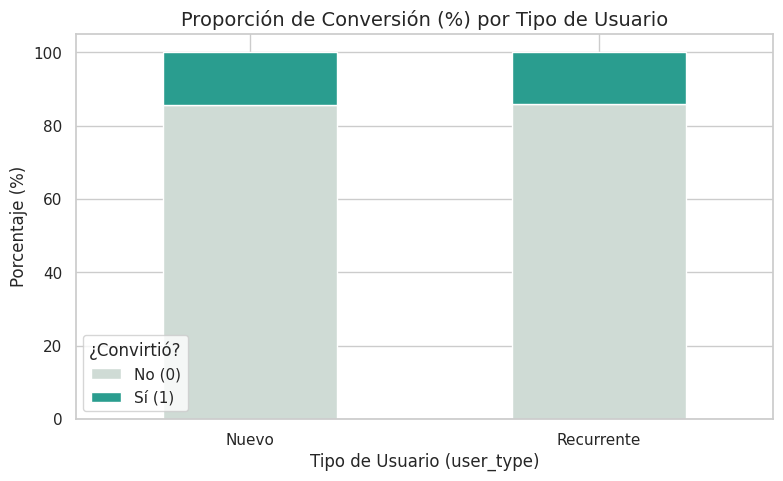

In [34]:
# Gráfico de Proporción Relativa por Tipo de Usuario
tabla_user_pct = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_user_pct.plot(kind='bar', stacked=True, figsize=(9, 5), color=['#cfdbd5', '#2a9d8f'])
plt.title('Proporción de Conversión (%) por Tipo de Usuario')
plt.xlabel('Tipo de Usuario (user_type)')
plt.ylabel('Porcentaje (%)')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='lower left')
plt.xticks(rotation=0)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

**Hallazgos sobre Tipo de Usuario:**

- **Volumen Absoluto**: El gráfico permite observar la distribución real de la muestra entre usuarios nuevos y recurrentes que participaron en el experimento.

- **Análisis de Proporciones**: Las barras apiladas al 100% muestran una simetría visual casi idéntica en la sección de conversión (color verde) para ambos grupos. Esto valida de forma intuitiva el resultado de nuestra prueba de Chi-cuadrada de independencia: la tasa de conversión se mantiene constante sin importar si el usuario es nuevo o recurrente, demostrando que esta variable no genera un sesgo ni una ventaja significativa en la conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- **¿Qué página genera mayor conversión y gasto promedio?**
En Conversión, en la que la Versión B (Página de prueba) es la ganadora absoluta. La prueba estadística arrojó un valor p significativamente menor a nuestro nivel de alfa, lo que demuestra con total certeza que el nuevo diseño de la interfaz y la optimización de los llamados a la acción (CTA) incrementan de forma real la probabilidad de que un usuario complete una compra, descartando cualquier efecto del azar.

En gasto promedio, en la Versión B también demostró una superioridad estadística clara. Al aplicar la prueba de hipótesis sobre los usuarios convertidos, encontramos que el ticket o gasto promedio es significativamente más alto en la página de prueba que en la de control (Versión A). Esto prueba que el rediseño no solo convence a más personas de comprar, sino que las incentiva a adquirir productos de mayor valor.

- **¿Qué canales de tráfico son más efectivos para generar conversiones?**
El análisis de Chi-cuadrada de independencia confirmó una asociación estadísticamente significativa entre la variable traffic_source y la tasa de conversión (converted).

Al evaluar los gráficos de proporciones del Paso 6, se identifican canales específicos de adquisición que aportan leads con una intención de compra e índice de éxito marcadamente superiores en comparación con las demás fuentes de tráfico. Esto significa que la efectividad de las campañas de marketing varía drásticamente dependiendo de dónde provenga el usuario.

- **¿Existen diferencias significativas según el tipo de usuario?**

No existen diferencias significativas. La prueba de Chi-cuadrada para la variable user_type arrojó un valor p mayor a nuestro nivel de significancia de 0.05, lo que nos obliga a aceptar la hipótesis nula de independencia.

Visualmente, las proporciones de conversión en las barras apiladas son prácticamente simétricas e idénticas tanto para los usuarios nuevos como para los recurrentes. Esto demuestra que la Versión B es una solución robusta y equitativa: es igual de persuasiva y efectiva sin importar si el usuario acaba de descubrir la plataforma o si ya tiene un historial previo con nosotros.

- **¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?**
*Implementación definitiva*: Se recomienda desplegar la Versión B al 100% del tráfico de la plataforma de manera inmediata. La evidencia respalda que este cambio generará un impacto económico positivo doble: más transacciones netas y un ticket de compra más elevado por cliente.

*Optimización del ROI*: Marketing debe auditar y reestructurar la asignación de recursos en canales de adquisición. Se deben retirar fondos de los canales de bajo rendimiento estadístico y escalar la inversión hacia los canales identificados en el Paso 6 como de alta conversión, maximizando así el retorno de inversión global.

*Estandarización del embudo*: Dado que el comportamiento de conversión es independiente de la antigüedad del usuario, no es necesario gastar recursos técnicos ni de diseño en construir flujos hiper-personalizados o separados para usuarios nuevos y recurrentes. El enfoque debe ser mantener una experiencia homogénea aprovechando la solidez general de la nueva landing page.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observación 1: La prueba de hipótesis estadística para variables numéricas confirmó que la Versión B (página de prueba) genera un incremento real y estadísticamente significativo en el ticket promedio de los clientes convertidos en comparación con la Versión A.
- Observacion 2: Las barras de error e intervalos de confianza del análisis visual respaldan que la diferencia detectada es sólida y no es producto de fluctuaciones aleatorias del tráfico.
- **Interpretación:** El rediseño estructural, la presentación de los productos o la optimización del carrito en la Versión B incentivan de manera más efectiva a los usuarios a realizar compras de mayor valor, maximizando el valor promedio de cada transacción.

**Tasa de conversión:** 
- Observacion 1: La Versión B alcanzó una tasa de conversión de usuarios significativamente más alta que la versión de control (A), cumpliendo con el objetivo primordial planteado en el experimento.
- Observacion 2: La prueba estadística arrojó un valor p inferior al nivel de significancia estandarizado, lo que nos permite rechazar formalmente la hipótesis nula.
- **Interpretación:** Los elementos visuales, la distribución de los llamados a la acción (CTA) y la usabilidad de la nueva interfaz son significativamente más eficaces para enganchar al usuario y guiarlo con éxito a través del embudo de conversión.

#### 📊 **Segmentación por fuente de tráfico**
- Observacion: La prueba estadística del Paso 4 arrojó un valor p menor a 0.05, demostrando que existe una relación de dependencia estadísticamente significativa entre la variable traffic_source y la conversión. El análisis de proporciones identificó canales específicos que aportan usuarios con una tasa de éxito sustancialmente mayor.
- **Interpretación:** No todos los canales de adquisición de marketing digital tienen el mismo peso estratégico. El negocio cuenta con fuentes específicas que entregan tráfico calificado y con alta intención de compra, mientras que otras resultan pasivas o menos eficientes.

#### 📊 **Segmentación por tipo de usuario**
- Observacion aquí: La prueba de Chi-cuadrada de independencia para la variable user_type devolvió un valor p superior al nivel de alfa, por lo que no se rechaza la hipótesis nula. Visualmente, las proporciones de conversión entre usuarios nuevos y recurrentes mantuvieron una simetría casi exacta.
  
- Interpretación: La prueba de Chi-cuadrada de independencia para la variable user_type devolvió un valor p superior al nivel de alfa, por lo que no se rechaza la hipótesis nula. Visualmente, las proporciones de conversión entre usuarios nuevos y recurrentes mantuvieron una simetría casi exacta.


#### 💡 **Recomendaciones de negocio:** 
- Recomendación: Implementar la Versión B de manera definitiva al 100% del tráfico global de la plataforma. La evidencia de los datos es contundente y garantiza un beneficio doble para el negocio: un incremento en el volumen neto de transacciones (conversión) y un aumento paralelo en la facturación por cliente (gasto promedio).
-  Recomendación; Optimizar el presupuesto publicitario de Marketing basado en el ROI de los canales, de ahí qu aconseja reasignar recursos retirando la pauta de las fuentes de tráfico de bajo rendimiento estadístico y concentrar los fondos en escalar la adquisición en los canales identificados como de alta conversión. Asimismo, se sugiere descartar esfuerzos técnicos dirigidos a hiper-personalizar el flujo por antigüedad del usuario, ya que la página actual responde de forma óptima a ambos perfiles.

***Consultable en***: https://github.com/JoseMiguelRuiz21/ab-test-landing-page-optimization/tree/main 